<a href="https://colab.research.google.com/github/vaibhavirawat/SimpleWebApp/blob/main/Tiny_AHE_IoT_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn matplotlib

In [5]:
from google.colab import files
uploaded = files.upload()

Saving train_test_network.csv to train_test_network (2).csv


In [6]:
import pandas as pd

df = pd.read_csv("train_test_network.csv")

print("Original shape:", df.shape)

df_small = df.sample(35000, random_state=42)

print("Sample shape:", df_small.shape)

df_small.to_csv("train_test_network_small.csv", index=False)

Original shape: (211043, 44)
Sample shape: (35000, 44)


In [8]:
%%writefile tiny_ahe_framework.py
# =============================================================================
# Tiny-AHE: Tiny Adaptive Hierarchical Ensemble for IoT Anomaly Detection
# =============================================================================
# Dataset  : train_test_network.csv  (211,043 rows)
# Features : 10 columns mapped from dataset to spec names
# Target   : label  (0 = Normal, 1 = Attack)
#
# Column mapping (dataset CSV → spec names used in code):
#   src_bytes    → orig_bytes
#   dst_bytes    → resp_bytes
#   src_pkts     → orig_pkts
#   dst_pkts     → resp_pkts
#   conn_state   → conn_state   ✓
#   service      → service      ✓
#   proto        → proto        ✓
#   duration     → duration     ✓
#   missed_bytes → missed_bytes ✓
#   conn_state   → history      (proxy — no 'history' col in this dataset)
#
# Compatible with: Google Colab / Jupyter Notebook
# Dependencies   : pandas, numpy, scikit-learn, matplotlib
# =============================================================================


# =============================================================================
# SECTION 1: IMPORTS
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")          # non-interactive backend (works in Colab too)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)


# =============================================================================
# SECTION 2: CONFIGURATION CONSTANTS
# =============================================================================

# ── Dataset path ─────────────────────────────────────────────────────────────
# Update this path if running in Colab (e.g. after uploading via files.upload())
DATASET_PATH = "train_test_network_small.csv"

# ── Feature names after renaming (spec-aligned) ───────────────────────────────
FEATURE_COLUMNS = [
    "duration", "orig_bytes", "resp_bytes", "orig_pkts", "resp_pkts",
    "conn_state", "service", "proto", "missed_bytes", "history"
]

# ── Categorical columns that require LabelEncoder ────────────────────────────
CATEGORICAL_COLUMNS = ["conn_state", "service", "proto", "history"]

# ── Target column ─────────────────────────────────────────────────────────────
TARGET_COLUMN = "label"

# ── Sensor model settings ─────────────────────────────────────────────────────
TOP_K_FEATURES            = 8      # SelectKBest top-K
HIGH_CONFIDENCE_THRESHOLD = 0.85   # below this → escalate to edge gateway

# ── Edge AHE: max training rows for SVM (SVM is O(n²); subsampled for speed) ─
# Set to None to train on the full training set (slower on large datasets).
SVM_MAX_TRAIN_SAMPLES = 20_000

# ── Train / test split ────────────────────────────────────────────────────────
TEST_SIZE    = 0.2
RANDOM_STATE = 42


# =============================================================================
# SECTION 3: DATA LOADING
# =============================================================================

def load_dataset(path: str) -> pd.DataFrame:
    """
    Load the IoT network CSV, select only the 10 required feature columns,
    rename them to spec-aligned names, and handle missing values.

    Note on column mapping:
      The dataset uses src_bytes / dst_bytes / src_pkts / dst_pkts
      instead of the spec's orig_bytes / resp_bytes / orig_pkts / resp_pkts.
      The dataset has no 'history' column — conn_state is reused as a proxy.
    """
    print(f"[INFO] Loading dataset from: {path}")

    # Only read the columns we need (memory efficient on large files)
    src_cols = [
        "duration", "src_bytes", "dst_bytes", "src_pkts", "dst_pkts",
        "conn_state", "service", "proto", "missed_bytes", TARGET_COLUMN
    ]
    df = pd.read_csv(path, usecols=src_cols)
    print(f"[INFO] Raw shape: {df.shape}")

    # Rename to spec-aligned feature names
    df.rename(columns={
        "src_bytes": "orig_bytes",
        "dst_bytes": "resp_bytes",
        "src_pkts" : "orig_pkts",
        "dst_pkts" : "resp_pkts",
    }, inplace=True)

    # Add 'history' as a proxy copy of 'conn_state'
    # (dataset has no history column; conn_state carries the closest semantics)
    df["history"] = df["conn_state"]

    # Handle missing values
    for col in FEATURE_COLUMNS:
        if col in CATEGORICAL_COLUMNS:
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].fillna(df[col].median())

    print(f"[INFO] Processed shape: {df.shape}")
    print(f"[INFO] Class distribution:\n{df[TARGET_COLUMN].value_counts()}\n")
    return df


# =============================================================================
# SECTION 4: FEATURE PREPROCESSING
# =============================================================================

def encode_categorical(df: pd.DataFrame):
    """
    Encode all categorical columns using LabelEncoder.
    Returns the modified DataFrame and a dict of fitted encoders.
    """
    df = df.copy()
    encoders = {}
    for col in CATEGORICAL_COLUMNS:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le
    print("[INFO] Categorical columns encoded successfully.")
    return df, encoders


def prepare_features(df: pd.DataFrame):
    """Extract feature matrix X and label vector y as NumPy arrays."""
    X = df[FEATURE_COLUMNS].values.astype(np.float32)
    y = df[TARGET_COLUMN].values.astype(int)
    return X, y


# =============================================================================
# SECTION 5: TINY SENSOR MODEL
# =============================================================================

class TinySensorModel:
    """
    Lightweight IoT sensor-side anomaly detector.

    Pipeline:
        Raw features
        → SelectKBest (mutual_info_classif, top-8)
        → MinMaxScaler
        → LogisticRegression (balanced class weights)
        → Confidence score via predict_proba()

    Decision logic:
        confidence >= HIGH_CONFIDENCE_THRESHOLD  →  local decision
        confidence <  HIGH_CONFIDENCE_THRESHOLD  →  escalate to Edge Gateway
    """

    def __init__(self, k: int = TOP_K_FEATURES,
                 threshold: float = HIGH_CONFIDENCE_THRESHOLD):
        self.k         = k
        self.threshold = threshold
        self.selector  = SelectKBest(score_func=mutual_info_classif, k=k)
        self.scaler    = MinMaxScaler()
        self.model     = LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
        self.is_trained = False

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        print("[Sensor] Selecting top features with SelectKBest...")
        X_sel = self.selector.fit_transform(X_train, y_train)

        selected_idx   = self.selector.get_support(indices=True)
        selected_names = [FEATURE_COLUMNS[i] for i in selected_idx]
        print(f"[Sensor] Top-{self.k} selected features : {selected_names}")

        print("[Sensor] Normalizing features with MinMaxScaler...")
        X_scaled = self.scaler.fit_transform(X_sel)

        print("[Sensor] Training Logistic Regression (Tiny Anomaly Detector)...")
        self.model.fit(X_scaled, y_train)

        self.is_trained = True
        print("[Sensor] Tiny sensor model trained successfully.\n")
        return self

    def _preprocess(self, X: np.ndarray) -> np.ndarray:
        """Apply fitted selector and scaler (inference mode)."""
        return self.scaler.transform(self.selector.transform(X))

    def predict_with_confidence(self, X: np.ndarray):
        """
        Returns:
            predictions   : 0/1 label for every sample
            confidences   : max class probability per sample
            escalate_mask : True → sample is uncertain → send to edge gateway
        """
        X_proc        = self._preprocess(X)
        probas        = self.model.predict_proba(X_proc)   # shape (N, 2)
        confidences   = np.max(probas, axis=1)
        predictions   = self.model.predict(X_proc)
        escalate_mask = confidences < self.threshold
        return predictions, confidences, escalate_mask

    def evaluate(self, X_test: np.ndarray, y_test: np.ndarray):
        """Report metrics on the high-confidence (locally decided) subset."""
        predictions, confidences, escalate_mask = self.predict_with_confidence(X_test)
        local_mask = ~escalate_mask

        print("=" * 60)
        print("  TINY SENSOR MODEL — High-Confidence Local Decisions")
        print("=" * 60)
        print(f"  Samples decided locally : {local_mask.sum():,} / {len(y_test):,}")
        print(f"  Samples escalated       : {escalate_mask.sum():,} / {len(y_test):,}")

        if local_mask.sum() > 0:
            _print_metrics(
                y_test[local_mask],
                predictions[local_mask],
                confidences[local_mask],
                label="Sensor"
            )
        return predictions, confidences, escalate_mask


# =============================================================================
# SECTION 6: CONFIDENCE-BASED ESCALATION LOGIC
# =============================================================================

def escalation_router(X_test: np.ndarray, y_test: np.ndarray,
                      sensor_model: TinySensorModel):
    """
    Route every test sample through the two-level decision process:
      • High-confidence (>= threshold) → sensor decides locally
      • Low-confidence  (<  threshold) → escalated to edge gateway

    Returns:
        X_escalated   : feature rows of uncertain samples
        y_escalated   : true labels of uncertain samples
        local_mask    : boolean mask for locally-decided samples
        escalate_mask : boolean mask for escalated samples
        predictions   : full-length sensor prediction array
        confidences   : full-length sensor confidence array
    """
    predictions, confidences, escalate_mask = sensor_model.predict_with_confidence(X_test)
    local_mask  = ~escalate_mask
    X_escalated = X_test[escalate_mask]
    y_escalated = y_test[escalate_mask]

    print(f"[Router] Total test samples   : {len(y_test):,}")
    print(f"[Router] Locally decided      : {local_mask.sum():,}  "
          f"({100 * local_mask.mean():.1f}%)")
    print(f"[Router] Escalated to gateway : {escalate_mask.sum():,}  "
          f"({100 * escalate_mask.mean():.1f}%)\n")

    return X_escalated, y_escalated, local_mask, escalate_mask, predictions, confidences


# =============================================================================
# SECTION 7: EDGE AHE ENSEMBLE MODEL
# =============================================================================

class EdgeAHEModel:
    """
    Edge Gateway — Adaptive Hierarchical Ensemble (AHE).

    Base learners (Level-0):
        1. RandomForestClassifier  — tree-based ensemble
        2. IsolationForest         — unsupervised anomaly scorer
        3. SVC (RBF kernel)        — margin-based probabilistic classifier

    Meta-learner (Level-1):
        LogisticRegression         — stacks base-learner P(attack) scores

    Stacking:
        Each base learner outputs a P(attack) ∈ [0,1].
        IsolationForest decision_function scores are min-max normalised and
        inverted (low score = anomaly = high attack probability).
        The meta-learner receives a (N, 3) matrix of these probabilities.

    SVM note:
        SVM training complexity is O(n²). For datasets with > 20K training rows
        we subsample SVM_MAX_TRAIN_SAMPLES rows (stratified) to keep training
        time practical. RF and IsolationForest always train on the full set.
    """

    def __init__(self, svm_max_samples: int = SVM_MAX_TRAIN_SAMPLES):
        self.svm_max_samples = svm_max_samples

        self.rf = RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        self.iso_forest = IsolationForest(
            n_estimators=100,
            contamination=0.1,
            random_state=RANDOM_STATE
        )
        self.svm = SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
        self.scaler       = MinMaxScaler()
        self.meta_learner = LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
        self.is_trained = False
        self._iso_min   = None
        self._iso_max   = None

    # ── Internal helpers ──────────────────────────────────────────────────────

    def _scale(self, X: np.ndarray, fit: bool = False) -> np.ndarray:
        return self.scaler.fit_transform(X) if fit else self.scaler.transform(X)

    def _iso_to_proba(self, scores: np.ndarray) -> np.ndarray:
        """Convert IsolationForest scores to attack probability in [0, 1]."""
        scores = np.clip(scores, self._iso_min, self._iso_max)
        normed = (scores - self._iso_min) / (self._iso_max - self._iso_min + 1e-9)
        return (1.0 - normed).reshape(-1, 1)   # low score → high P(attack)

    def _build_meta_features(self, X_scaled: np.ndarray,
                              calibrate_iso: bool = False) -> np.ndarray:
        """Build (N, 3) stacked meta-feature matrix from base learner outputs."""
        rf_p  = self.rf.predict_proba(X_scaled)[:, 1].reshape(-1, 1)

        iso_s = self.iso_forest.decision_function(X_scaled)
        if calibrate_iso:
            self._iso_min = iso_s.min()
            self._iso_max = iso_s.max()
        iso_p = self._iso_to_proba(iso_s)

        svm_p = self.svm.predict_proba(X_scaled)[:, 1].reshape(-1, 1)

        return np.hstack([rf_p, iso_p, svm_p])   # (N, 3)

    # ── Training ──────────────────────────────────────────────────────────────

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        print("[Edge AHE] Scaling features...")
        X_scaled = self._scale(X_train, fit=True)

        print(f"[Edge AHE] Training RandomForest  ({X_scaled.shape[0]:,} rows)...")
        self.rf.fit(X_scaled, y_train)

        print(f"[Edge AHE] Training IsolationForest ({X_scaled.shape[0]:,} rows)...")
        self.iso_forest.fit(X_scaled)

        # Subsample for SVM if training set is large
        if self.svm_max_samples and X_scaled.shape[0] > self.svm_max_samples:
            rng = np.random.RandomState(RANDOM_STATE)
            idx = rng.choice(X_scaled.shape[0], size=self.svm_max_samples, replace=False)
            X_svm, y_svm = X_scaled[idx], y_train[idx]
            print(f"[Edge AHE] Training SVM on subsample ({self.svm_max_samples:,} rows)...")
        else:
            X_svm, y_svm = X_scaled, y_train
            print(f"[Edge AHE] Training SVM ({X_scaled.shape[0]:,} rows)...")
        self.svm.fit(X_svm, y_svm)

        print("[Edge AHE] Building stacked meta-feature matrix...")
        meta_X = self._build_meta_features(X_scaled, calibrate_iso=True)

        print("[Edge AHE] Training Logistic Regression meta-learner...")
        self.meta_learner.fit(meta_X, y_train)

        self.is_trained = True
        print("[Edge AHE] Edge AHE model trained successfully.\n")
        return self

    # ── Inference ─────────────────────────────────────────────────────────────

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        X_scaled = self._scale(X)
        meta_X   = self._build_meta_features(X_scaled)
        return self.meta_learner.predict_proba(meta_X)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

    def evaluate(self, X_test: np.ndarray, y_test: np.ndarray):
        """Evaluate AHE on escalated (uncertain) samples."""
        if len(X_test) == 0:
            print("[Edge AHE] No escalated samples to evaluate.\n")
            return None, None

        y_pred  = self.predict(X_test)
        y_proba = self.predict_proba(X_test)[:, 1]

        print("=" * 60)
        print("  EDGE AHE MODEL — Escalated Samples Evaluation")
        print("=" * 60)
        _print_metrics(y_test, y_pred, y_proba, label="Edge AHE")
        return y_pred, y_proba


# =============================================================================
# SECTION 8: EVALUATION METRICS
# =============================================================================

def _print_metrics(y_true, y_pred, y_proba, label="Model"):
    """Compute and print Accuracy, Precision, Recall, F1, and ROC-AUC."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_proba)
    except ValueError:
        auc = float("nan")

    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print("=" * 60 + "\n")
    return acc, prec, rec, f1, auc


def compute_full_system_metrics(
    y_test        : np.ndarray,
    sensor_preds  : np.ndarray,
    sensor_probas : np.ndarray,
    local_mask    : np.ndarray,
    escalate_mask : np.ndarray,
    edge_preds    : np.ndarray,
    edge_probas   : np.ndarray,
):
    """
    Merge sensor (local) and edge (escalated) decisions into a single
    unified result array and compute system-wide classification metrics.
    """
    final_preds  = np.zeros(len(y_test), dtype=int)
    final_probas = np.zeros(len(y_test), dtype=float)

    # Sensor-decided samples
    final_preds[local_mask]  = sensor_preds[local_mask]
    final_probas[local_mask] = sensor_probas[local_mask]

    # Edge-decided samples
    if escalate_mask.sum() > 0 and edge_preds is not None:
        final_preds[escalate_mask]  = edge_preds
        final_probas[escalate_mask] = edge_probas

    print("=" * 60)
    print("  FULL SYSTEM — Combined Evaluation (Sensor + Edge)")
    print("=" * 60)
    _print_metrics(y_test, final_preds, final_probas, label="System")
    return final_preds, final_probas


# =============================================================================
# SECTION 9: VISUALIZATION
# =============================================================================

def plot_confidence_distribution(confidences: np.ndarray, threshold: float,
                                  save_path: str = None):
    """Histogram of sensor confidence scores with escalation threshold line."""
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(confidences, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(x=threshold, color="crimson", linestyle="--", lw=2,
               label=f"Threshold = {threshold}")
    ax.set_xlabel("Confidence Score")
    ax.set_ylabel("Sample Count")
    ax.set_title("Sensor Model — Confidence Score Distribution")
    ax.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120)
        print(f"[VIZ] Saved → {save_path}")
    plt.show()
    print("[VIZ] Confidence distribution plotted.\n")


def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray,
                          title: str = "Confusion Matrix",
                          save_path: str = None):
    """Annotated confusion matrix heatmap."""
    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    im  = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)

    classes    = ["Normal (0)", "Attack (1)"]
    tick_marks = np.arange(len(classes))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(classes, rotation=25, ha="right")
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(classes)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"), ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")
    ax.set_title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120)
        print(f"[VIZ] Saved → {save_path}")
    plt.show()
    print(f"[VIZ] Confusion Matrix plotted: {title}\n")


def plot_roc_curve(y_true: np.ndarray, y_proba: np.ndarray,
                   title: str = "ROC Curve", save_path: str = None):
    """ROC curve with AUC score annotation."""
    try:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc_score   = roc_auc_score(y_true, y_proba)
    except ValueError as e:
        print(f"[VIZ] Could not compute ROC curve: {e}\n")
        return

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc_score:.4f}")
    ax.plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1, label="Random")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(loc="lower right")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120)
        print(f"[VIZ] Saved → {save_path}")
    plt.show()
    print(f"[VIZ] ROC Curve plotted: {title}\n")


# =============================================================================
# MAIN PIPELINE
# =============================================================================

def main():
    print("\n" + "=" * 64)
    print("  Tiny-AHE: Adaptive Hierarchical Ensemble for IoT Security")
    print("  Dataset  : train_test_network.csv  (211,043 rows)")
    print("=" * 64 + "\n")

    # ── 3. DATA LOADING ──────────────────────────────────────────────────────
    df = load_dataset(DATASET_PATH)

    # ── 4. FEATURE PREPROCESSING ─────────────────────────────────────────────
    df, _ = encode_categorical(df)
    X, y  = prepare_features(df)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
    )
    print(f"[INFO] Train samples : {X_train.shape[0]:,}")
    print(f"[INFO] Test samples  : {X_test.shape[0]:,}\n")

    # ── 5. TRAIN TINY SENSOR MODEL ────────────────────────────────────────────
    sensor = TinySensorModel(k=TOP_K_FEATURES, threshold=HIGH_CONFIDENCE_THRESHOLD)
    sensor.fit(X_train, y_train)

    # ── 6. CONFIDENCE-BASED ESCALATION ───────────────────────────────────────
    print("[INFO] Escalation summary:")
    (X_escalated, y_escalated,
     local_mask, escalate_mask,
     sensor_preds, sensor_conf) = escalation_router(X_test, y_test, sensor)

    # Evaluate sensor on locally-decided (high-confidence) samples
    sensor.evaluate(X_test, y_test)

    # ── 7. TRAIN EDGE AHE ENSEMBLE ────────────────────────────────────────────
    edge = EdgeAHEModel(svm_max_samples=SVM_MAX_TRAIN_SAMPLES)
    edge.fit(X_train, y_train)

    # Evaluate edge model on the escalated subset
    edge_preds_esc, edge_probas_esc = edge.evaluate(X_escalated, y_escalated)

    # ── 8. FULL SYSTEM EVALUATION ─────────────────────────────────────────────
    # Build full-length edge arrays (zero-filled where sensor decided locally)
    edge_preds_full  = np.zeros(len(y_test), dtype=int)
    edge_probas_full = np.zeros(len(y_test), dtype=float)
    if escalate_mask.sum() > 0 and edge_preds_esc is not None:
        edge_preds_full[escalate_mask]  = edge_preds_esc
        edge_probas_full[escalate_mask] = edge_probas_esc

    final_preds, final_probas = compute_full_system_metrics(
        y_test        = y_test,
        sensor_preds  = sensor_preds,
        sensor_probas = sensor_conf,
        local_mask    = local_mask,
        escalate_mask = escalate_mask,
        edge_preds    = edge_preds_full[escalate_mask] if escalate_mask.sum() > 0 else np.array([]),
        edge_probas   = edge_probas_full[escalate_mask] if escalate_mask.sum() > 0 else np.array([]),
    )

    # ── 9. VISUALIZATION ──────────────────────────────────────────────────────
    # 9a — Sensor confidence score distribution
    plot_confidence_distribution(sensor_conf, HIGH_CONFIDENCE_THRESHOLD,
                                  save_path="plot_confidence.png")

    # 9b — Full system confusion matrix
    plot_confusion_matrix(y_test, final_preds,
                          title="Tiny-AHE System — Confusion Matrix",
                          save_path="plot_system_cm.png")

    # 9c — Full system ROC curve
    plot_roc_curve(y_test, final_probas,
                   title="Tiny-AHE System — ROC Curve",
                   save_path="plot_system_roc.png")

    # 9d — Edge AHE plots for escalated samples only
    if escalate_mask.sum() > 0 and edge_preds_esc is not None:
        plot_confusion_matrix(y_escalated, edge_preds_esc,
                              title="Edge AHE — Confusion Matrix (Escalated)",
                              save_path="plot_edge_cm.png")
        plot_roc_curve(y_escalated, edge_probas_esc,
                       title="Edge AHE — ROC Curve (Escalated)",
                       save_path="plot_edge_roc.png")

    print("[INFO] Tiny-AHE pipeline completed successfully.")
    print("[INFO] Plot images saved to current directory.")


# =============================================================================
# ENTRY POINT
# =============================================================================
if __name__ == "__main__":
    main()

Overwriting tiny_ahe_framework.py


In [9]:
!python tiny_ahe_framework.py


  Tiny-AHE: Adaptive Hierarchical Ensemble for IoT Security
  Dataset  : train_test_network.csv  (211,043 rows)

[INFO] Loading dataset from: train_test_network_small.csv
[INFO] Raw shape: (35000, 10)
[INFO] Processed shape: (35000, 11)
[INFO] Class distribution:
label
1    26715
0     8285
Name: count, dtype: int64

[INFO] Categorical columns encoded successfully.
[INFO] Train samples : 28,000
[INFO] Test samples  : 7,000

[Sensor] Selecting top features with SelectKBest...
[Sensor] Top-8 selected features : ['duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'conn_state', 'service', 'proto', 'history']
[Sensor] Normalizing features with MinMaxScaler...
[Sensor] Training Logistic Regression (Tiny Anomaly Detector)...
[Sensor] Tiny sensor model trained successfully.

[INFO] Escalation summary:
[Router] Total test samples   : 7,000
[Router] Locally decided      : 2,780  (39.7%)
[Router] Escalated to gateway : 4,220  (60.3%)

  TINY SENSOR MODEL — High-Confidence Local Decisions
  Sam

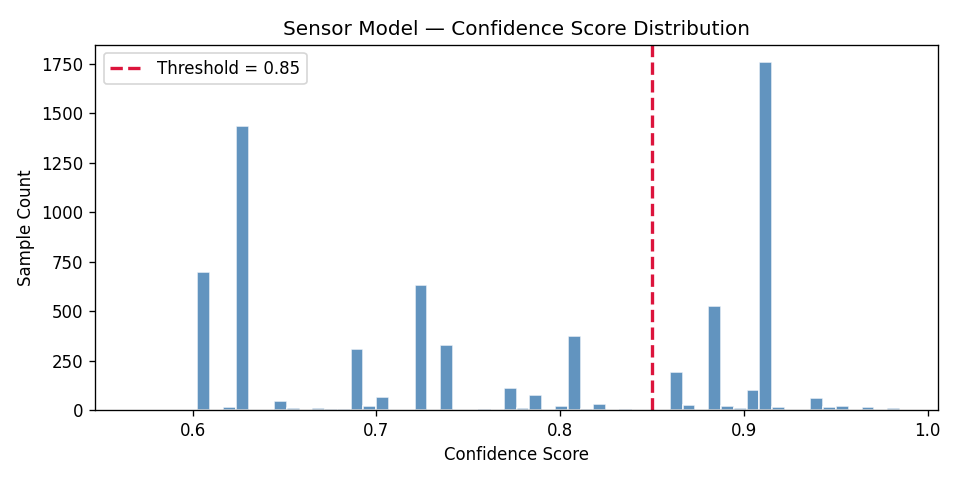

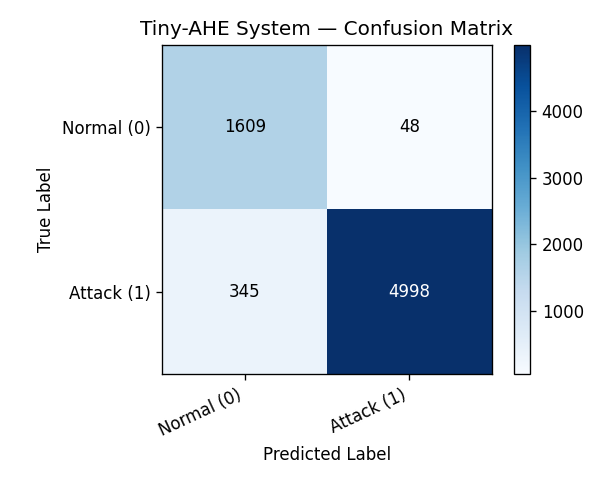

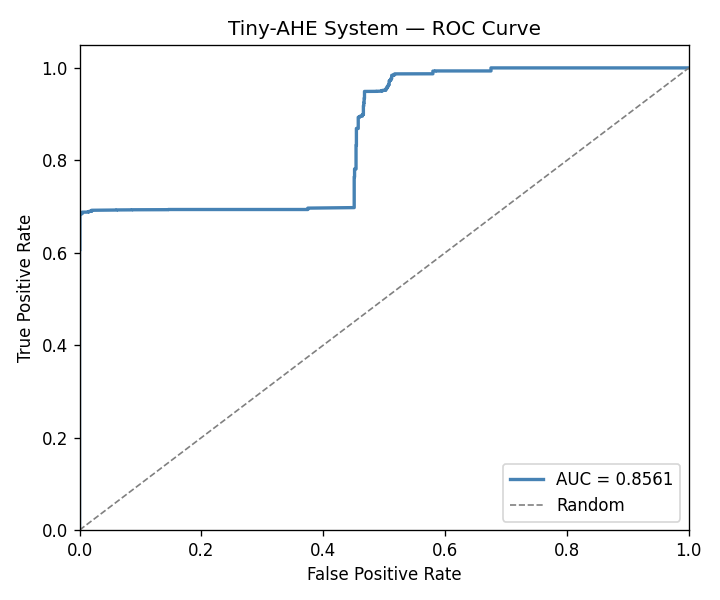

In [10]:
from IPython.display import Image, display

display(Image("plot_confidence.png"))
display(Image("plot_system_cm.png"))
display(Image("plot_system_roc.png"))

In [11]:
from google.colab import files

files.download("plot_system_cm.png")
files.download("plot_system_roc.png")
files.download("plot_confidence.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>